Name: Laura Perkins  
NetID: LLP34  

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import fxns_for_ACE as fxn
import importlib
importlib.reload(fxn)

ace = pd.read_csv("Agrofood_co2_emission.csv")

#print(".head()")
ace.head()
#print(".info()")
#ace.info()
#print(".describe()")
#ace.describe()

,Area,Year,Savanna fires,Forest fires,Crop Residues,Rice Cultivation,Drained organic soils (CO2),Pesticides Manufacturing,Food Transport,Forestland,...,Manure Management,Fires in organic soils,Fires in humid tropical forests,On-farm energy use,Rural population,Urban population,Total Population - Male,Total Population - Female,total_emission,Average Temperature °C
0,Afghanistan,1990,14.7237,0.0557,205.6077,686.00,0.0,11.807483,63.1152,-2388.803,...,319.1763,0.0,0.0,NaN,9655167.0,2593947.0,5348387.0,5346409.0,2198.963539,0.536167
1,Afghanistan,1991,14.7237,0.0557,209.4971,678.16,0.0,11.712073,61.2125,-2388.803,...,342.3079,0.0,0.0,NaN,10230490.0,2763167.0,5372959.0,5372208.0,2323.876629,0.020667
2,Afghanistan,1992,14.7237,0.0557,196.5341,686.00,0.0,11.712073,53.3170,-2388.803,...,349.1224,0.0,0.0,NaN,10995568.0,2985663.0,6028494.0,6028939.0,2356.304229,-0.259583
3,Afghanistan,1993,14.7237,0.0557,230.8175,686.00,0.0,11.712073,54.3617,-2388.803,...,352.2947,0.0,0.0,NaN,11858090.0,3237009.0,7003641.0,7000119.0,2368.470529,0.101917
4,Afghanistan,1994,14.7237,0.0557,242.0494,705.60,0.0,11.712073,53.9874,-2388.803,...,367.6784,0.0,0.0,NaN,12690115.0,3482604.0,7733458.0,7722096.0,2500.768729,0.372250


In [3]:
fxn.workingfxns()

The above code reads a csv from the kaggle database about co2 emissions in agricultural sectors.  

It provides some basic summaries using the .head(), .info(), and .describe() functions.



## Question 1: Did forest fires impact a forest's future ability to sequester CO2?
This would include analysis on "forest fires" and "fires in humid tropical forests" over time and changes in total_emission

Sum forest fires and fires in humid tropical forests
Create a line graph, I believe that seing how the shape of the trends over time will be the most beneficial.

In [6]:
# making a new df for forest fires with the columns 'Area', 'Year', 'total_emission', and 'Forestland' from the ace df
og_col = ['Area', 'Year', 'total_emission', 'Forestland']
# new column 'total_fires' will be added to the new df, which will be the sum of the 'Forest fires' and 'Fires in humid tropical forests' columns from the ace df
forest_fires = fxn.new_df(ace, og_col, 'total_fires')

forest_fires = fxn.add_columns(ace, forest_fires, 'Forest fires', 'Fires in humid tropical forests', 'total_fires')
forest_fires.head()

,Area,Year,total_emission,Forestland,total_fires
0,Afghanistan,1990,2198.963539,-2388.803,0.0557
1,Afghanistan,1991,2323.876629,-2388.803,0.0557
2,Afghanistan,1992,2356.304229,-2388.803,0.0557
3,Afghanistan,1993,2368.470529,-2388.803,0.0557
4,Afghanistan,1994,2500.768729,-2388.803,0.0557


I decided that I am going to display the plot for the United States
Year on the X axis
total_fires on the left hand Y axis
total_emission on the right hand Y axis
Note: AI was used to assist in making the code for the following graphs

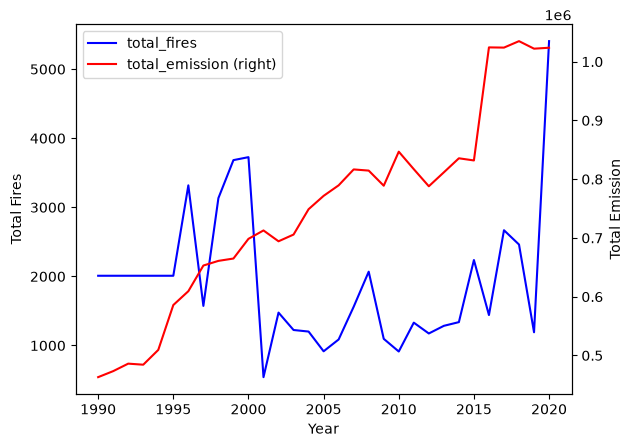

In [7]:
#generate new df of forest fires and emissions for the USA
usa_fires = forest_fires[forest_fires['Area'] == 'United States of America'].copy()
usa_fires.head()

#generate line plot for the USA with year on the x-axis and total_fires and total_emission on the y-axis
ax = usa_fires.plot(x = "Year", y = "total_fires", color = 'blue', label = 'total_fires')
usa_fires.plot(x = "Year", y = "total_emission", color = 'red', label = 'total_emission', ax = ax, secondary_y = True)
ax.set_ylabel("Total Fires")
ax.right_ax.set_ylabel("Total Emission")
ax.set_xlabel("Year")
plt.show()

Based on this graph, I would say it is difficult to tell whether an increase in emissions follors forest fires.

Part of the confounding factors may be that the USA is a large country, so lets look at a different country, Greece.

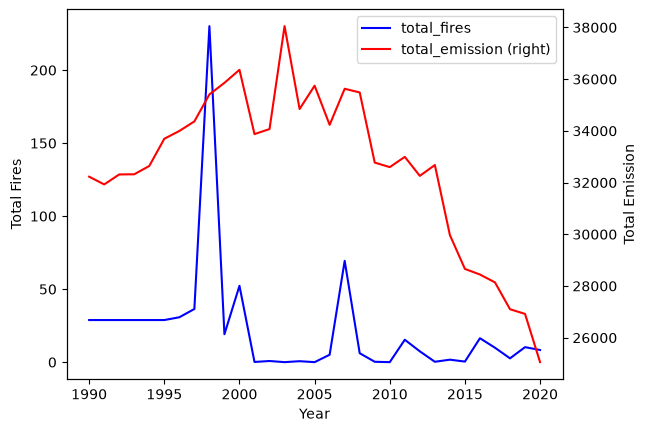

In [8]:
#generate new df of forest fires and emissions for Greece
greece_fires = forest_fires[forest_fires['Area'] == 'Greece'].copy()
greece_fires.head()

#generate line plot for Greece with year on the x-axis and total_fires and total_emission on the y-axis
ax = greece_fires.plot(x = "Year", y = "total_fires", color = 'blue', label = 'total_fires')
greece_fires.plot(x = "Year", y = "total_emission", color = 'red', label = 'total_emission', ax = ax, secondary_y = True)
ax.set_ylabel("Total Fires")
ax.right_ax.set_ylabel("Total Emission")
ax.set_xlabel("Year")
plt.show()

Its possible. The prominent peak in the late 90s is followed by a prominent peak in the early 2000s.

# Question 2: total emission and population ratio

We will now begin our comparison of total emission and the urban/rural population ratio.

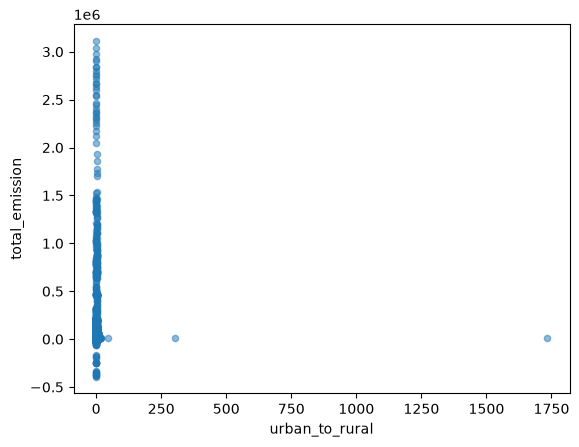

In [10]:
#create new df with only the 'Area', 'Year', 'Total Population - Male', 'Total Population - Female', and 'total_emission' columns. 
total_population = fxn.new_df(ace, ['Area', 'Year', 'total_emission'], 'total_population')

#Add a new column called 'total_population' that contains the sum of the male and female populations.
total_population = fxn.add_columns(ace, total_population, 'Total Population - Male', 'Total Population - Female', 'total_population')
#Divide `Urban population` by `Rural population`. Store as a new column called `urban_to_rural`.
total_population['urban_to_rural'] = ace['Rural population'] / ace['Urban population']
#Create a scatter plot of population ratio versus normalized emissions.
total_population.plot.scatter(x = 'urban_to_rural', y = 'total_emission', alpha = 0.5)
plt.show()


The above plot is not very informative as there are two outliers that compress the area of highest density. Therefore, we will proceed by removing the outlier around 1750 from our set.

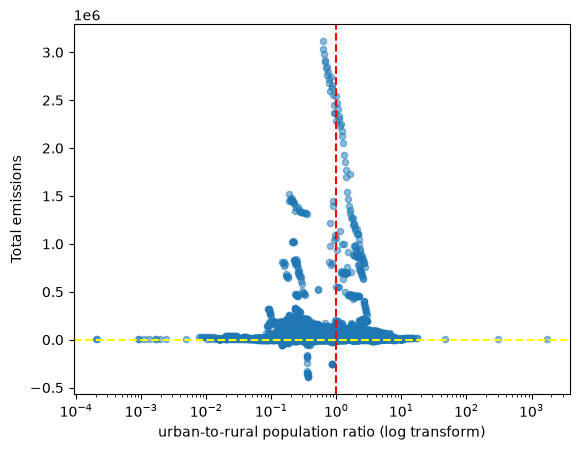

In [11]:

no_outliers = total_population.copy()

no_outliers = no_outliers[no_outliers['urban_to_rural'] < 200]

total_population.plot.scatter(x = 'urban_to_rural', y = 'total_emission', alpha = 0.5)
plt.axvline(x=1, color='red', linestyle='--')
plt.xscale('log')
plt.xlabel('urban-to-rural population ratio (log transform)')
plt.ylabel('Total emissions')
plt.axhline(y=0, color='yellow', linestyle='--')
plt.show()

This gives us a much more informative graph. 
I have included a red line at x = 1 (where the urban population = rural population).
From this, we notice that most are gathered hear the the center of the graph; however, there is a distinct trend where the total CO2 emission decreases as the population ratio increases.

I then generated a density plot (mostly because it is pretty).

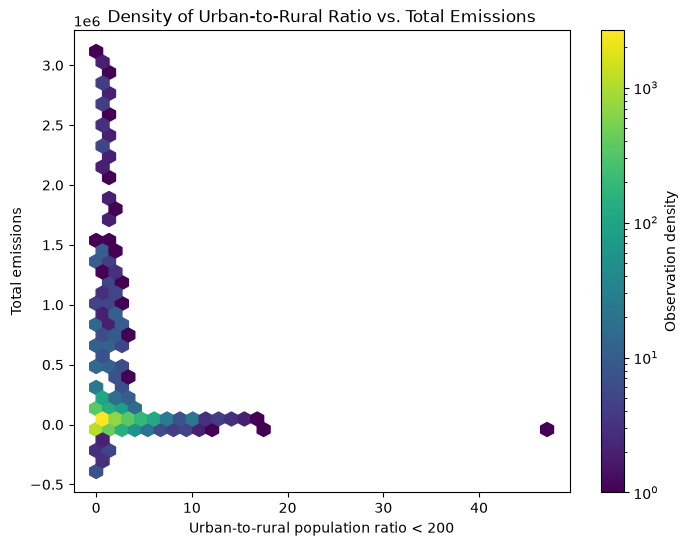

In [12]:
#this was made entirely with AI because I was curios. I am keeping it because I think it is pretty :)
plt.figure(figsize=(8, 6))
plt.hexbin(
    no_outliers['urban_to_rural'],
    no_outliers['total_emission'],
    gridsize=35,
    bins='log',
    mincnt=1,
    cmap='viridis'
)

plt.colorbar(label='Observation density')
plt.xlabel('Urban-to-rural population ratio < 200')
plt.ylabel('Total emissions')
plt.title('Density of Urban-to-Rural Ratio vs. Total Emissions')
plt.show()


## Question 3: Highest correlation to total emission
Here we utilize scikit-learn to identify the best models for correlating each characteristic to total_emission.

We begin by producing 4 models for each characteristic for each area.

**Important note:** *The following code was made with AI. Honestly, I don't understand some of it as I have never used scikit-learn, but I think most of it makes sense to me*


In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = []

# note: this will take several minutes to run because I wanted to look at a lot of models
for area, area_data in ace.groupby('Area'):
    for column in ace.columns[2:31]:

        # Avoid using total_emission to predict itself
        if column == 'total_emission':
            continue

        model_data = (
            area_data[[column, 'total_emission']]
            .apply(pd.to_numeric, errors='coerce')
            .dropna()
            .sort_index()
        )

        if len(model_data) < 8 or model_data[column].nunique() < 2:
            continue

        X = model_data[[column]]
        y = model_data['total_emission']

        split_index = int(len(model_data) * 0.8)

        X_train = X.iloc[:split_index]
        X_test = X.iloc[split_index:]
        y_train = y.iloc[:split_index]
        y_test = y.iloc[split_index:]

        models = {
            'linear': LinearRegression(),
            'polynomial_degree_2': make_pipeline(
                PolynomialFeatures(degree=2),
                LinearRegression()
            ),
            'polynomial_degree_3': make_pipeline(
                PolynomialFeatures(degree=3),
                LinearRegression()
            ),
            'random_forest': RandomForestRegressor(
                n_estimators=200,
                random_state=42,
                min_samples_leaf=2
            )
        }

        for model_name, model in models.items():
            model.fit(X_train, y_train)
            predictions = model.predict(X_test)

            results.append({
                'Area': area,
                'predictor': column,
                'model': model_name,
                'MAE': mean_absolute_error(y_test, predictions),
                'RMSE': np.sqrt(mean_squared_error(y_test, predictions)),
                'R2': r2_score(y_test, predictions)
            })




In [14]:
results_df = pd.DataFrame(results)
results_df.head()

,Area,predictor,model,MAE,RMSE,R2
0,Afghanistan,Savanna fires,linear,6284.070864,6329.664729,-131.289882
1,Afghanistan,Savanna fires,polynomial_degree_2,5327.344783,5499.823604,-98.876367
2,Afghanistan,Savanna fires,polynomial_degree_3,4784.730530,5230.104576,-89.320422
3,Afghanistan,Savanna fires,random_forest,5125.744823,5321.855554,-92.517175
4,Afghanistan,Forest fires,linear,6669.517085,6692.182990,-146.877067


In order to determine the best model, we will filter for the model with the lowest RMSE value. The others are important, but this tends to be a good starting point.

In [15]:
best_models = (
    results_df
    .sort_values(['Area', 'predictor', 'RMSE'])
    .groupby(['Area', 'predictor'])
    .first()
    .reset_index()
)

best_models.head(30)

,Area,predictor,model,MAE,RMSE,R2
0,Afghanistan,Agrifood Systems Waste Disposal,polynomial_degree_2,306.152974,324.688762,0.651903
1,Afghanistan,Average Temperature °C,polynomial_degree_3,6114.499481,6466.624482,-137.076732
2,Afghanistan,Crop Residues,random_forest,4403.352746,4593.905262,-68.683392
3,Afghanistan,Fertilizers Manufacturing,polynomial_degree_3,4593.548645,4630.368492,-69.793979
4,Afghanistan,Food Household Consumption,random_forest,2228.604361,2295.546215,-16.399521
5,Afghanistan,Food Packaging,linear,1217.196012,1335.822278,-4.891998
6,Afghanistan,Food Processing,linear,300.027483,423.960630,0.406506
7,Afghanistan,Food Retail,random_forest,2233.914625,2300.701975,-16.477767
8,Afghanistan,Food Transport,polynomial_degree_2,2722.403078,2751.268729,-23.993739
9,Afghanistan,Forest fires,random_forest,4837.969124,4869.168335,-77.284322


Now that we have the "best" (again, not necessarily, but a good quick, starting point) model we will sort the table by the highest R2 values to see which indicators may be the best for each area

In [16]:
best_R2 = (
    best_models
    .sort_values(['R2'], ascending=False)
)

best_R2.head(30)

,Area,predictor,model,MAE,RMSE,R2
2345,Isle of Man,Rice Cultivation,polynomial_degree_2,12.721692,13.503116,0.999946
4333,Solomon Islands,Forestland,linear,260.899316,268.309459,0.999913
3917,Romania,Forestland,linear,2895.131676,3203.198814,0.999270
926,Channel Islands,Agrifood Systems Waste Disposal,polynomial_degree_3,35.917177,93.283938,0.998888
4839,Turks and Caicos Islands,Rice Cultivation,polynomial_degree_2,8.943714,10.505837,0.998835
5154,Wallis and Futuna Islands,Rice Cultivation,polynomial_degree_3,0.281798,0.293524,0.997703
4338,Solomon Islands,Net Forest conversion,polynomial_degree_2,1232.054251,1394.472614,0.997653
90,Andorra,Food Processing,linear,13.097287,16.598691,0.994580
1572,Estonia,Forestland,linear,205.341880,243.386669,0.992870
2863,Malaysia,Net Forest conversion,polynomial_degree_3,6954.175233,9870.874910,0.986774


This provides a potential starting point for further investigation. However, it is important to note that high R2 values are not indicative of causation, and could even be due to over-fitting the data.